<a href="https://colab.research.google.com/github/Pascingo/CTA-media-analysis/blob/main/01_Stage1_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata


os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")

os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
!kaggle datasets download -d jannalipenkova/ai-media-dataset

!unzip -o ai-media-dataset.zip

print("Download and unpacking done.")

Dataset URL: https://www.kaggle.com/datasets/jannalipenkova/ai-media-dataset
License(s): MIT
100% 169M/169M [00:02<00:00, 60.2MB/s]

Archive:  ai-media-dataset.zip
  inflating: ai_media_dataset_20260911.csv  
Download and unpacking done.


We import the "AI-Media"-Dataset directly from Kaggle via the Kaggle API. By importing the dataset this way, we can ensure that it's always actual.

In [ ]:
import pandas as pd
import re

file_name = "ai_media_dataset_20260911.csv"
df = pd.read_csv(file_name)

print(f"Original dataset shape: {df.shape}")
print("Found columns:", df.columns.tolist())

TEXT_COLUMN = 'content'

Original dataset shape: (47751, 7)
Found columns: ['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']


We import the dataset and transform it into a pandas-dataframe. The original dataset consists of seven columns and 47751 rows. Our work is going to concern the content of the AI Media articles, so we fix the "content" column as our text column. By doing this, we can simplify our code later on.

In [ ]:
# Data Cleaning


# remove duplicates
df = df.drop_duplicates(subset=[TEXT_COLUMN])

# Remove rows with NaN
df = df.dropna(subset=[TEXT_COLUMN])
print(f"Shape after drops: {df.shape}")

# Normalizing Text
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Casing: All in lowercase
    text = re.sub(r'<[^>]+>', ' ', text) # Remove HTML-Tags
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text) # Remove irrelevant symbols (keep ".,!?")
    text = re.sub(r'\s+', ' ', text).strip() # Remove Leerschläge
    return text

df['cleaned_text'] = df[TEXT_COLUMN].apply(clean_text)


Shape after drops: (47685, 7)


The next step is cleaning our data. We remove duplicate articles and drop all rows containing NA's. Next we normalize the text, ensuring everything is lowercase, contains no HTML-tags, has no symbols except ".,!?" those give context on the sentence. We remove duplicated spaces and return the dataframe. After all drops, the dataset consists of 47685 rows. The columns stay the same.

In [ ]:
'''
Pilot with track 1 "Governance"
'''
governance_keywords = [
    'security', 'accountability', 'bias', 'fairness',
    'regulatory', 'regulation', 'governance', 'policy',
    'ethics', 'compliance', 'law'
]

pattern = '|'.join([rf'\b{kw}\b' for kw in governance_keywords])

# Only keep rows with one of the keywords
df_gov = df[df['cleaned_text'].str.contains(pattern, case=False, na=False, regex=True)]

print(f"Size of  'AI Governance' Dataset: {df_gov.shape}")

# Safe a new dataset to simplyfy teamwork
df_gov.to_csv('ai_governance_cleaned.csv', index=False)
print("Cleaned dataset saved as 'ai_governance_cleaned.csv'.")

# Checking the results
display(df_gov[['title', 'date', 'cleaned_text']].head(3))

Size of  'AI Governance' Dataset: (31600, 8)
Cleaned dataset saved as 'ai_governance_cleaned.csv'.


,title,date,cleaned_text
0,Top 10 AI Companies in UK & Europe,2024-09-11,with the field of ai accelerating all the time...
1,“ Winner ” Takes Political Comedy Seriously,2024-09-11,"this was in 2017, and she believed that the pu..."
4,How GCCs are shaping the future of business,2024-09-11,enterprises are looking to global capability c...


We chose track 1 to pursue in our work. We define some general governance keywords. Using those keywords, we filter the rows and keep only those that contain those words. The size of our AI Governance Dataset is 31600 rows.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

df_gov = df_gov.copy()
df_gov['n_characters'] = df_gov['cleaned_text'].str.len()
df_gov['n_whitespace_tokens'] = df_gov['cleaned_text'].str.split().str.len()

print("\n--- AI Governance: Stats ---") # Exactly like in the class
audit = pd.DataFrame({
    "documents": [len(df_gov)],
    "min_tokens": [int(df_gov["n_whitespace_tokens"].min())],
    "median_tokens": [float(df_gov["n_whitespace_tokens"].median())],
    "max_tokens": [int(df_gov["n_whitespace_tokens"].max())],
})
display(audit)


--- AI Governance: Stats ---


,documents,min_tokens,median_tokens,max_tokens
0,31600,319,1296.0,9523


:Blabla 31'600 dokumente, Median Tokens wären 1296

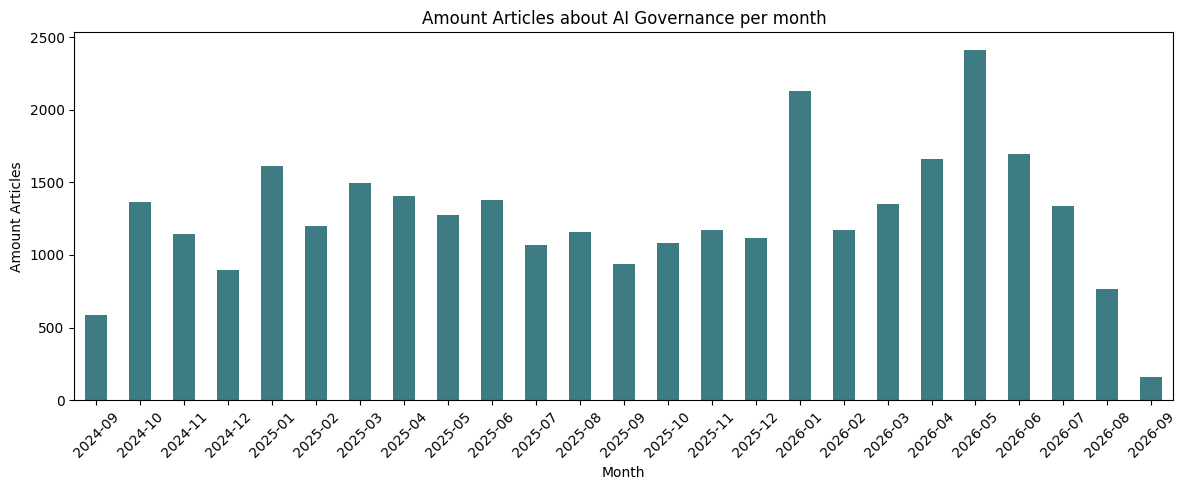

In [ ]:
df_gov['published_at'] = pd.to_datetime(df_gov['date'], errors='coerce')

plt.figure(figsize=(12, 5))
df_gov.groupby(df_gov['published_at'].dt.to_period("M")).size().plot(kind='bar', color='#3D7C83')
plt.title('Amount Articles about AI Governance per month')
plt.xlabel('Month')
plt.ylabel('Amount Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Blabla regelmässige Berichterstattung. Wahrscheinlich kommen Themen mit neuen Frontier-Models und ihren Fähigkeiten, müsste überprüft werden

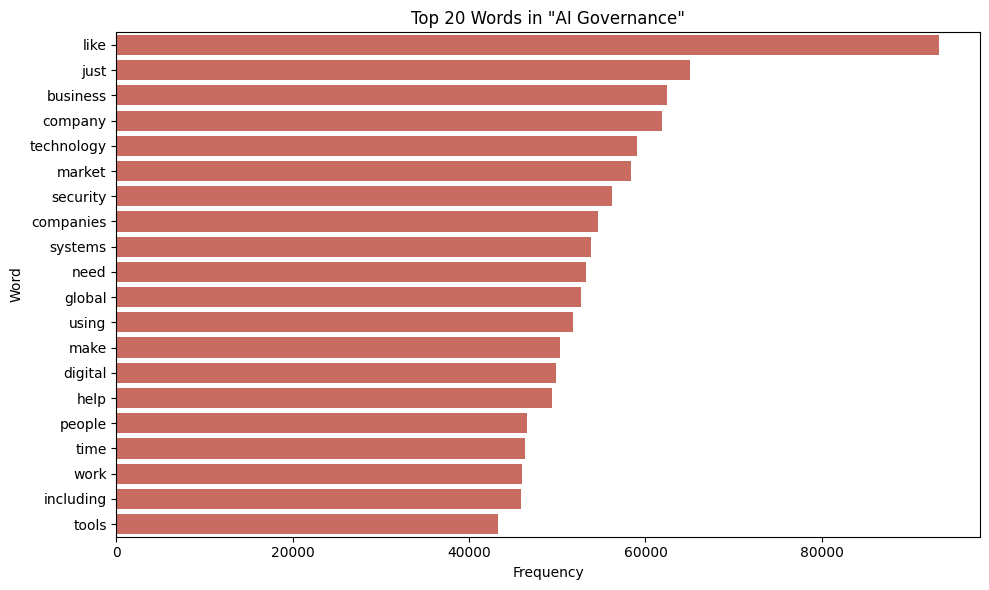

In [ ]:
# Word count: Warning takes forever. Skip to next code to get optimized counting (by AI)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


# Add AI-Words into the existing list

stop_words = list(ENGLISH_STOP_WORDS) + ['ai', 'artificial', 'intelligence', 'model', 'models', 'data', 'said', 'new', 'use']

def get_top_n_words(corpus, n=20):
    vec = Counter()
    for text in corpus:
        words = [word for word in text.split() if word not in stop_words and len(word) > 2]
        vec.update(words)
    return vec.most_common(n)

top_words = get_top_n_words(df_gov['cleaned_text'], 20)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='Frequency', y='Word', color='#D95D4F')
plt.title('Top 20 Words in "AI Governance"')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Sehr viele Füllwörter drin und nichts sinnvolles. 1. Muss dringend beschleunigt werden, zweitens müssen Füllwörter entnommen werden können.





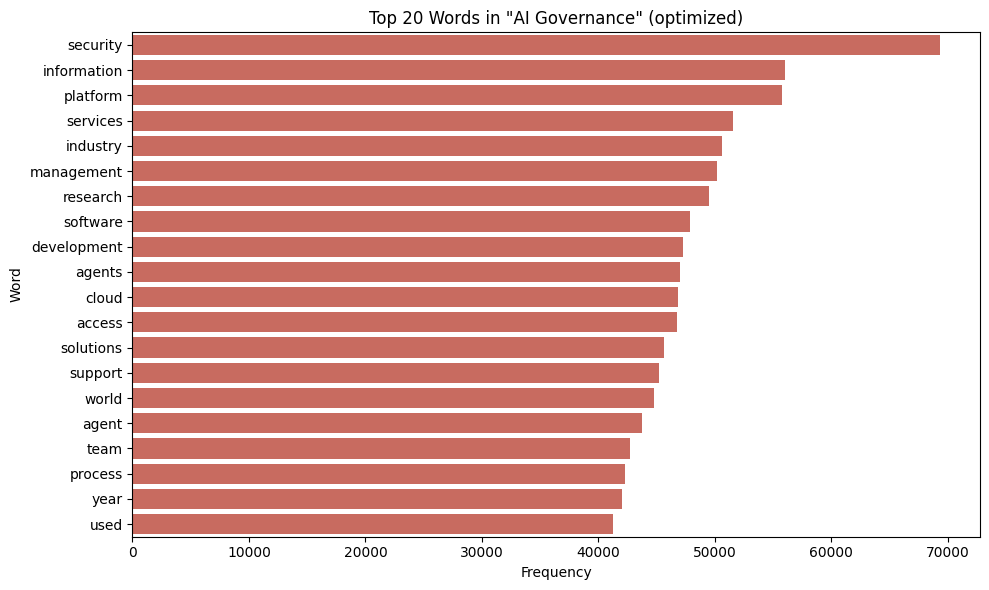

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# Optimized TOP KEYWORDS & TRENDS ---

# 1. Added more Stop Words from Chart above + AI words
custom_stops = [
    'like', 'just', 'business', 'company', 'companies', 'make', 'need',
    'using', 'help', 'people', 'time', 'work', 'including', 'tools',
    'systems', 'market', 'global', 'digital', 'technology', 'ai',
    'artificial', 'intelligence', 'model', 'models', 'data', 'said', 'new', 'use'
]
all_stopwords = list(ENGLISH_STOP_WORDS) + custom_stops

# 2. Using vectorizer to be faster
vectorizer = CountVectorizer(stop_words=all_stopwords, max_features=20)
word_counts = vectorizer.fit_transform(df_gov['cleaned_text'])

# 3. Words and Frequency indexing
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

top_words_df = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='Frequency', y='Word', color='#D95D4F')
plt.title('Top 20 Words in "AI Governance" (optimized)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Sieht deutlich besser aus